# BioHub Cell Tracking During Development
## Chapter 46A — Multi-Sample Pipeline Artifact Generation (v7)

**Purpose:** Reproduce the historical **Chapter 34 → Chapter 35 → Chapter 36 → Chapter 37** pipeline across additional training samples so the existing Chapter 46 audit can measure division failures across more than one event.

### Reproducibility contract

This is an **artifact-generation / reproduction notebook**, not a model-improvement notebook.

It will:

- use the exact historical Chapter 34–37 notebooks as the algorithm source of truth;
- record their SHA-256 hashes;
- discover training samples containing at least one **binary ground-truth division**;
- use target-sample ground truth only for **sample selection and division counting**;
- run each selected sample independently so tracks can never cross sample boundaries;
- preserve historical settings and thresholds;
- add `sample_id` and globally-qualified track IDs to combined outputs;
- report failed stages explicitly rather than silently dropping samples;
- package all CSV artifacts into `chapter46a_multisample_pipeline_artifacts.zip`.

### Chapter 36 leakage safeguard

The historical Chapter 36 notebook contains an optional supervised temporal classifier. Chapter 46A **must not re-train that classifier on each new target sample**. If a frozen historical model is available, it may be applied unchanged. Otherwise, Chapter 46A uses the historical **label-free temporal support score** and records that mode in the validation table. No new target sample is used to fit a Chapter 36 model.

### Required outputs

- `chapter34_top200_detections_multisample.csv`
- `chapter35_track_nodes_multisample.csv`
- `chapter35_track_edges_multisample.csv`
- `chapter35_track_summary_multisample.csv`
- `chapter36_filtered_detections_multisample.csv`
- `chapter36_filtered_track_nodes_multisample.csv`
- `chapter36_filtered_track_edges_multisample.csv`
- `chapter37_refined_track_nodes_multisample.csv`
- `chapter37_refined_track_edges_multisample.csv`
- `chapter37_refined_track_summary_multisample.csv`
- `chapter46a_sample_summary.csv`
- `chapter46a_validation.csv`
- `chapter46a_failures.csv`
- `chapter46a_selected_samples.csv`
- `chapter46a_source_manifest.csv`
- `chapter46a_multisample_pipeline_artifacts.zip`

> **v2 fix:** GT sample discovery now uses the same Zarr-backed `load_geff_tables()` structure as the existing Chapter 46 audit, replacing the incorrect generic JSON GEFF parser.

> **v3 fix:** historical notebook replay now executes inside real module-backed namespaces registered in `sys.modules`. This fixes the Python 3.12 `@dataclass` replay error seen while bootstrapping Chapter 34, without modifying Chapter 34's algorithm.

> **v4 fix:** Chapter 34 replay no longer assumes globals named `model` and `feature_columns`. It inspects the actual historical `run_detection_pipeline()` signature and resolves only what that function requires.

> **v5 fix:** historical definition replay now extracts functions, classes, imports, constants, and `CONFIG = *Config(...)` assignments from mixed notebook cells individually. This prevents reusable functions such as Chapter 35's `track_sequence()` from being skipped just because their cell also contains top-level notebook execution code.

> **v6 smoke-test fix:** runs only one selected sample by default and supplies Chapter 34 with the actual historical inputs: the sample microscopy `raw_volume`, frozen ranking model, historical feature columns, all timepoints, and a sample-specific `DetectionConfig`. The final cell reports failure instead of raising, so a smoke test cannot waste a full-cohort run.

> **v7 fix:** Chapter 34 model discovery now rejects imported estimator classes and selects only a fitted estimator instance. V6 mistakenly selected the `HistGradientBoostingRegressor` class itself, causing the unbound `predict()` TypeError.

In [1]:
!pip install -q zarr networkx scipy scikit-learn nbformat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 69.4 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

from dataclasses import dataclass, replace
from pathlib import Path
from typing import Any, Optional
import ast
import inspect
import sys
import types
import hashlib
import json
import re
import traceback
import urllib.request
import zipfile
import warnings

import nbformat
import networkx as nx
import numpy as np
import pandas as pd
import zarr

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

## 1. Configuration

In [3]:
@dataclass(frozen=True)
class Config:
    competition_dir: Path = Path(
        "/kaggle/input/competitions/biohub-cell-tracking-during-development"
    )
    output_dir: Path = Path("/kaggle/working/chapter46a")
    source_dir: Path = Path("/kaggle/working/chapter46a/historical_sources")
    per_sample_dir: Path = Path("/kaggle/working/chapter46a/per_sample")

    repo_owner: str = "AskChristopher"
    repo_name: str = "biohub-cell-tracking"
    repo_branch: str = "main"

    historical_sample_id: str = "44b6_12dfb391"

    source_notebooks: tuple[str, ...] = (
        "chapter-34-end-to-end-detection-pipeline.ipynb",
        "chapter-35-motion-aware-tracking-with-gap-closin.ipynb",
        "chapter-36-track-aware-detection-filtering.ipynb",
        "chapter-37-track-refinement-and-gap-closing.ipynb",
    )

    strict_complete: bool = False

    # Set to 1 or 2 for a smoke test. Leave None for all selected samples.
    max_selected_samples: Optional[int] = 1

CONFIG = Config()
CONFIG.output_dir.mkdir(parents=True, exist_ok=True)
CONFIG.source_dir.mkdir(parents=True, exist_ok=True)
CONFIG.per_sample_dir.mkdir(parents=True, exist_ok=True)
CONFIG

Config(competition_dir=PosixPath('/kaggle/input/competitions/biohub-cell-tracking-during-development'), output_dir=PosixPath('/kaggle/working/chapter46a'), source_dir=PosixPath('/kaggle/working/chapter46a/historical_sources'), per_sample_dir=PosixPath('/kaggle/working/chapter46a/per_sample'), repo_owner='AskChristopher', repo_name='biohub-cell-tracking', repo_branch='main', historical_sample_id='44b6_12dfb391', source_notebooks=('chapter-34-end-to-end-detection-pipeline.ipynb', 'chapter-35-motion-aware-tracking-with-gap-closin.ipynb', 'chapter-36-track-aware-detection-filtering.ipynb', 'chapter-37-track-refinement-and-gap-closing.ipynb'), strict_complete=False, max_selected_samples=1)

## 2. Acquire the exact historical Chapter 34–37 source notebooks

The notebook first searches attached Kaggle inputs for exact filenames. If a source notebook is not attached, it downloads the public repository copy. A SHA-256 manifest is saved for provenance.

In [4]:
def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def find_attached_notebook(filename: str) -> Optional[Path]:
    root = Path("/kaggle/input")
    if not root.exists():
        return None
    matches = list(root.rglob(filename))
    return matches[0] if matches else None


def github_raw_url(filename: str) -> str:
    return (
        f"https://raw.githubusercontent.com/"
        f"{CONFIG.repo_owner}/{CONFIG.repo_name}/"
        f"{CONFIG.repo_branch}/{filename}"
    )


def acquire_source(filename: str) -> tuple[Path, str]:
    target = CONFIG.source_dir / filename
    attached = find_attached_notebook(filename)

    if attached is not None:
        target.write_bytes(attached.read_bytes())
        return target, f"kaggle_input:{attached}"

    url = github_raw_url(filename)
    try:
        urllib.request.urlretrieve(url, target)
        return target, f"github:{url}"
    except Exception as exc:
        raise FileNotFoundError(
            f"Could not acquire {filename}. Attach the four historical notebooks "
            "as a Kaggle Dataset or enable Internet. "
            f"Download error: {exc}"
        ) from exc


SOURCE_PATHS = {}
source_rows = []

for filename in CONFIG.source_notebooks:
    path, source = acquire_source(filename)
    SOURCE_PATHS[filename] = path
    source_rows.append(
        {
            "filename": filename,
            "source": source,
            "sha256": sha256_file(path),
            "bytes": path.stat().st_size,
        }
    )

source_manifest = pd.DataFrame(source_rows)
source_manifest.to_csv(
    CONFIG.output_dir / "chapter46a_source_manifest.csv", index=False
)
display(source_manifest)

,filename,source,sha256,bytes
0,chapter-34-end-to-end-detection-pipeline.ipynb,github:https://raw.githubusercontent.com/AskCh...,e41c9c86f78a941097a12af2119d9c2aabfef840316f0f...,1870995
1,chapter-35-motion-aware-tracking-with-gap-clos...,github:https://raw.githubusercontent.com/AskCh...,d562295be3459a4b14f5f7e4897942b3cecb4a16dbb070...,383505
2,chapter-36-track-aware-detection-filtering.ipynb,github:https://raw.githubusercontent.com/AskCh...,c5b8711fe79bdfc21ec3784fbaa15bac7edf27ec2fb3f1...,182364
3,chapter-37-track-refinement-and-gap-closing.ipynb,github:https://raw.githubusercontent.com/AskCh...,4321d296ad2fc4a43833f04e84756a7f87d020fd9b8a3b...,424984


## 3. Discover binary GT divisions and freeze the target cohort

A binary division is a GT graph node with **exactly two outgoing edges**.

Ground truth is used only in this section to select samples and count divisions. After `selected_samples` is created, the new target cohort is frozen and target GT is not consulted by Chapters 34–37.

In [5]:
def find_train_dir() -> Path:
    for candidate in (
        CONFIG.competition_dir / "train",
        CONFIG.competition_dir / "training",
    ):
        if candidate.exists():
            return candidate

    geff = list(CONFIG.competition_dir.rglob("*.geff"))
    if geff:
        return geff[0].parent

    raise FileNotFoundError(
        f"Could not locate training GEFF data below {CONFIG.competition_dir}"
    )


TRAIN_DIR = find_train_dir()
print("Training directory:", TRAIN_DIR)


def sample_id_from_geff(path: Path) -> str:
    return path.name[:-5] if path.name.endswith(".geff") else path.stem


def load_geff_tables(geff_path: Path):
    """
    Proven GEFF loader copied from the existing Chapter 46 audit.

    BioHub GEFF samples are Zarr stores. The node table is stored under:
      nodes/ids
      nodes/props/t/values
      nodes/props/z/values
      nodes/props/y/values
      nodes/props/x/values

    Edges are stored under:
      edges/ids

    Ground truth loaded here is used ONLY to select samples and count divisions.
    """
    geff = zarr.open(geff_path, mode="r")

    nodes = pd.DataFrame({
        "gt_node_id": np.asarray(geff["nodes/ids"][:]),
        "t": np.asarray(geff["nodes/props/t/values"][:]).astype(int),
        "z": np.asarray(geff["nodes/props/z/values"][:]).astype(float),
        "y": np.asarray(geff["nodes/props/y/values"][:]).astype(float),
        "x": np.asarray(geff["nodes/props/x/values"][:]).astype(float),
    })

    edge_ids = np.asarray(geff["edges/ids"][:])

    edges = pd.DataFrame({
        "gt_source": edge_ids[:, 0],
        "gt_target": edge_ids[:, 1],
    })

    return nodes, edges


def count_binary_divisions(sample_id: str, geff_path: Path):
    """
    Count GT binary divisions exactly as Chapter 46 does:
    parent node out-degree == 2.

    Also record out-degree > 2 events separately.
    """
    nodes, edges = load_geff_tables(geff_path)

    out_degree = edges.groupby("gt_source").size()

    binary_parents = out_degree[out_degree == 2]
    unusual_parents = out_degree[out_degree > 2]

    return {
        "sample_id": sample_id,
        "gt_binary_divisions": int(len(binary_parents)),
        "gt_outdegree_gt2_events": int(len(unusual_parents)),
        "geff_path": str(geff_path),
        "selection_error": "",
    }, [
        {
            "sample_id": sample_id,
            "parent_gt_id": parent_id,
            "out_degree": int(degree),
        }
        for parent_id, degree in unusual_parents.items()
    ]


geff_paths = sorted(TRAIN_DIR.glob("*.geff"))

if not geff_paths:
    geff_paths = sorted(TRAIN_DIR.rglob("*.geff"))

if not geff_paths:
    raise FileNotFoundError(
        f"No .geff samples found under {TRAIN_DIR}"
    )


division_rows = []
unusual_rows = []

for geff_path in geff_paths:
    sample_id = sample_id_from_geff(geff_path)

    try:
        row, unusual = count_binary_divisions(
            sample_id,
            geff_path,
        )
        division_rows.append(row)
        unusual_rows.extend(unusual)

    except Exception as exc:
        division_rows.append({
            "sample_id": sample_id,
            "gt_binary_divisions": np.nan,
            "gt_outdegree_gt2_events": np.nan,
            "geff_path": str(geff_path),
            "selection_error": f"{type(exc).__name__}: {exc}",
        })


division_counts = pd.DataFrame(division_rows)

selected_samples = (
    division_counts[
        (division_counts["selection_error"] == "")
        & (division_counts["gt_binary_divisions"] >= 1)
    ]
    .sort_values(
        ["gt_binary_divisions", "sample_id"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

if CONFIG.max_selected_samples is not None:
    selected_samples = selected_samples.head(
        CONFIG.max_selected_samples
    ).copy()


selected_samples.to_csv(
    CONFIG.output_dir / "chapter46a_selected_samples.csv",
    index=False,
)

pd.DataFrame(unusual_rows).to_csv(
    CONFIG.output_dir / "chapter46a_unusual_gt_branching.csv",
    index=False,
)


failed_gt_reads = division_counts[
    division_counts["selection_error"] != ""
].copy()

print("Training samples discovered:", len(division_counts))
print(
    "Samples whose GEFF GT loaded successfully:",
    int((division_counts["selection_error"] == "").sum()),
)
print(
    "Samples whose GEFF GT failed to load:",
    len(failed_gt_reads),
)
print(
    "Selected samples with >=1 binary GT division:",
    len(selected_samples),
)

display(selected_samples)

if len(failed_gt_reads):
    print("\nGEFF read failures (first 10):")
    display(
        failed_gt_reads[
            ["sample_id", "selection_error"]
        ].head(10)
    )


# Sanity check against the known historical division sample.
known = division_counts[
    division_counts["sample_id"].astype(str)
    == CONFIG.historical_sample_id
]

if len(known) != 1:
    raise RuntimeError(
        "Known historical sample "
        f"{CONFIG.historical_sample_id!r} was not found exactly once."
    )

known_binary_count = known.iloc[0]["gt_binary_divisions"]
known_error = known.iloc[0]["selection_error"]

print(
    "\nKnown historical sample sanity check:",
    CONFIG.historical_sample_id,
    "| binary GT divisions:",
    known_binary_count,
    "| error:",
    known_error or "none",
)

if known_error:
    raise RuntimeError(
        "The proven GEFF loader could not read the known historical sample. "
        f"Error: {known_error}"
    )

if int(known_binary_count) < 1:
    raise RuntimeError(
        "GEFF discovery sanity check failed: the known historical sample "
        f"{CONFIG.historical_sample_id} should contain at least one binary division."
    )

if selected_samples.empty:
    raise RuntimeError(
        "No samples with binary GT divisions were discovered even though "
        "the GEFF loader passed the known-sample sanity check."
    )

print(
    "\nGT discovery passed. The target cohort is now frozen. "
    "Chapters 34–37 will not use target-sample GT."
)

Training directory: /kaggle/input/competitions/biohub-cell-tracking-during-development/train
Training samples discovered: 199
Samples whose GEFF GT loaded successfully: 199
Samples whose GEFF GT failed to load: 0
Selected samples with >=1 binary GT division: 1


,sample_id,gt_binary_divisions,gt_outdegree_gt2_events,geff_path,selection_error
0,6bba_48816121,5,0,/kaggle/input/competitions/biohub-cell-trackin...,



Known historical sample sanity check: 44b6_12dfb391 | binary GT divisions: 1 | error: none

GT discovery passed. The target cohort is now frozen. Chapters 34–37 will not use target-sample GT.


## 4. Historical source execution helpers

These helpers reuse algorithm cells from the historical notebooks. Only orchestration-level changes are allowed: input paths, output directories, sample ID, and skipping target-GT evaluation/training sections.

In [6]:
def load_nb(path: Path):
    return nbformat.read(path, as_version=4)


def clean_ipython_code(source: str) -> str:
    # Dependencies are installed by Chapter 46A.
    # Shell/magic lines cannot be compiled with Python exec().
    kept = []
    for line in source.splitlines():
        stripped = line.lstrip()
        if stripped.startswith("!") or stripped.startswith("%"):
            continue
        kept.append(line)
    return "\n".join(kept)


def section_map(nb):
    sections = []
    heading = "__preamble__"
    code_cells = []

    def flush():
        nonlocal code_cells
        if code_cells:
            sections.append((heading, code_cells))
            code_cells = []

    for cell in nb.cells:
        if cell.cell_type == "markdown":
            hs = [
                x.strip()
                for x in cell.source.splitlines()
                if x.strip().startswith("## ")
            ]
            if hs:
                flush()
                heading = hs[-1]
        elif cell.cell_type == "code":
            code_cells.append(cell.source)

    flush()
    return sections


def exec_code(source: str, ns: dict[str, Any], label: str):
    source = clean_ipython_code(source)
    if not source.strip():
        return
    try:
        exec(compile(source, label, "exec"), ns, ns)
    except Exception as exc:
        raise RuntimeError(
            f"{label}: {type(exc).__name__}: {exc}"
        ) from exc


def make_exec_namespace(module_name: str) -> dict[str, Any]:
    module = types.ModuleType(module_name)
    sys.modules[module_name] = module
    ns = module.__dict__
    ns.update({"Path": Path, "np": np, "pd": pd, "zarr": zarr, "nx": nx,
               "linear_sum_assignment": linear_sum_assignment, "cdist": cdist,
               "display": display})
    return ns


def _literal_only(node):
    if isinstance(node, ast.Constant): return True
    if isinstance(node,(ast.List,ast.Tuple,ast.Set)): return all(_literal_only(x) for x in node.elts)
    if isinstance(node,ast.Dict): return all((k is None or _literal_only(k)) and _literal_only(v) for k,v in zip(node.keys,node.values))
    if isinstance(node,ast.UnaryOp): return _literal_only(node.operand)
    if isinstance(node,ast.BinOp): return _literal_only(node.left) and _literal_only(node.right)
    return False


def _assignment_names(node):
    targets=node.targets if isinstance(node,ast.Assign) else [node.target]
    return [t.id for t in targets if isinstance(t,ast.Name)]


def bootstrap_definition_cells(nb, label: str) -> dict[str, Any]:
    ns=make_exec_namespace(f"__{label}_defs__")
    imports=[]; classes=[]; literals=[]; configs=[]; functions=[]
    for heading,sources in section_map(nb):
        for source in sources:
            cleaned=clean_ipython_code(source)
            if not cleaned.strip(): continue
            try: tree=ast.parse(cleaned)
            except SyntaxError: continue
            for node in tree.body:
                if isinstance(node,ast.Import): imports.append(node); continue
                if isinstance(node,ast.ImportFrom):
                    if node.module!='__future__': imports.append(node)
                    continue
                if isinstance(node,ast.ClassDef): classes.append(node); continue
                if isinstance(node,(ast.FunctionDef,ast.AsyncFunctionDef)): functions.append(node); continue
                if isinstance(node,(ast.Assign,ast.AnnAssign)):
                    names=_assignment_names(node); value=node.value
                    if _literal_only(value): literals.append(node); continue
                    if 'CONFIG' in names and isinstance(value,ast.Call):
                        func=value.func
                        if isinstance(func,ast.Name) and func.id.lower().endswith('config'):
                            configs.append(node); continue
    synthetic=ast.Module(body=imports+literals+classes+configs+functions,type_ignores=[])
    ast.fix_missing_locations(synthetic)
    try:
        exec(compile(synthetic,f"<{label}-historical-definitions>",'exec'),ns,ns)
    except Exception as exc:
        raise RuntimeError(f"Could not bootstrap reusable definitions for {label}: {type(exc).__name__}: {exc}") from exc
    return ns


def run_heading_sections(
    nb,
    ns: dict[str, Any],
    include_patterns: list[str],
    skip_patterns: list[str] | None = None,
):
    skip_patterns = skip_patterns or []

    for heading, sources in section_map(nb):
        if not any(
            re.search(p, heading, flags=re.I)
            for p in include_patterns
        ):
            continue

        if any(
            re.search(p, heading, flags=re.I)
            for p in skip_patterns
        ):
            continue

        for i, source in enumerate(sources):
            exec_code(
                source,
                ns,
                f"{heading} / cell {i}",
            )


def qualify_track_ids(df: pd.DataFrame, sample_id: str) -> pd.DataFrame:
    out = df.copy()
    if "sample_id" not in out.columns:
        out.insert(0, "sample_id", sample_id)

    for col in (
        "track_id",
        "source_track_id",
        "target_track_id",
        "parent_track_id",
        "daughter_track_id",
    ):
        if col in out.columns:
            out[f"global_{col}"] = (
                sample_id + "::" + out[col].astype(str)
            )

    return out

## 5. Bootstrap the historical Chapter 34 detector

The historical Chapter 34 source defines a reusable `run_detection_pipeline(sample_id, model, feature_columns)` function. Chapter 46A reconstructs that detector state from the original source once, then applies it unchanged to the frozen target cohort.

If the current historical source no longer exposes those objects, the notebook stops rather than inventing a replacement detector.

DetectionConfig(sample_id='44b6_12dfb391', nms_radius=3.0, oracle_radius=6.0, target_distance_clip=20.0, graph_radius_physical=12.0, max_graph_neighbors=16, patch_radius_2d=4, patch_radius_z=2, patch_radius_xy=4, top_k=200, train_timesteps=(0, 8, 20, 40), validation_timesteps=(60, 80), coordinate_scale_zyx=(1.625, 0.40625, 0.40625))
Image path: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_12dfb391.zarr
GEFF path: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_12dfb391.geff
Image shape: (100, 64, 256, 256)
Image dtype: uint16
GT nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


t=0: raw=7795, rankable=1768, oracle_good=31, time=9.0s
t=8: raw=7696, rankable=1823, oracle_good=32, time=9.0s
t=20: raw=7968, rankable=1859, oracle_good=31, time=9.2s
t=40: raw=8022, rankable=1941, oracle_good=35, time=9.1s
Training rows: 7391


,t,raw_candidates,rankable_candidates,oracle_good_candidates,proposal_gt_recall,elapsed_seconds
0,0,7795,1768,31,1.0,8.980456
1,8,7696,1823,32,1.0,8.964058
2,20,7968,1859,31,1.0,9.245898
3,40,8022,1941,35,1.0,9.138179


,z,y,x,sigma,proposal_count,proposal_sources,proposal_peak_intensity,center_intensity,patch_mean,patch_max,patch_std,local_contrast,center_to_patch_max_dist,patch_com_offset,is_near_border,center_voxel,vol_mean,vol_std,vol_max,z_line_mean,z_line_std,z_line_max,center_over_vol_mean,center_minus_vol_mean,center_slice_minus_neighbor_mean,slice_mean_std,z_peak_offset,mass_center_offset_3d,peak_to_mean_ratio,bright_fraction,graph_neighbor_count,graph_mean_neighbor_distance,graph_min_neighbor_distance,graph_mean_neighbor_intensity,graph_mean_neighbor_contrast,graph_mean_neighbor_proposal_count,t,nearest_gt_dist,target_dist,oracle_good
0,48,86,128,3.250,4,large_sensitive|medium_sensitive|medium_strict...,3140.0,3140.0,2135.111084,3140.0,671.388611,1004.888916,0.0,0.203683,0,3140.0,1809.446899,658.314575,3140.0,2513.800049,558.484863,3140.0,1.735337,1330.553101,165.252930,379.372437,0,0.275548,1.735337,0.496296,9.0,8.831360,4.958913,1498.444458,319.792847,1.666667,0,41.821049,20.0,False
1,55,81,255,3.625,4,large_sensitive|medium_sensitive|medium_strict...,3013.0,3013.0,2453.733398,3013.0,341.650726,559.266602,2.0,0.161669,1,3013.0,2235.088867,638.692200,3517.0,2698.000000,704.911072,3388.0,1.348045,777.911133,134.744629,541.989990,2,1.931775,1.573539,0.511111,14.0,8.727782,4.942245,1789.857178,334.454498,1.857143,0,71.805290,20.0,False
2,53,183,224,3.750,4,large_sensitive|medium_sensitive|medium_strict...,2721.0,2721.0,2086.185303,2721.0,372.735138,634.814697,0.0,0.035425,0,2721.0,1894.185181,433.850555,2734.0,2416.600098,234.425766,2721.0,1.436502,826.814819,101.808838,195.754013,1,0.100649,1.443365,0.518519,14.0,7.672420,2.333729,1944.428589,445.109406,1.571429,0,110.186203,20.0,False
3,56,10,255,3.250,4,large_sensitive|medium_sensitive|medium_strict...,2346.0,2346.0,1821.955566,2346.0,285.270233,524.044434,2.0,0.150015,1,2346.0,1767.640015,265.910980,2346.0,2051.000000,250.521057,2346.0,1.327193,578.359985,27.688965,146.235489,0,1.923731,1.327193,0.528889,16.0,7.837432,3.275292,1871.812500,298.832336,1.500000,0,86.011627,20.0,False
4,28,170,53,3.250,4,large_sensitive|medium_sensitive|medium_strict...,2288.0,2288.0,1744.012329,2288.0,311.872192,543.987671,0.0,0.141893,0,2288.0,1438.604980,359.430237,2288.0,1812.000000,358.675903,2288.0,1.590430,849.395020,196.376587,236.075500,0,0.175454,1.590430,0.498765,16.0,8.388052,3.447145,1720.812500,309.719910,1.562500,0,27.367865,20.0,False


Training MAE: 0.7343918386091896
t=60: raw=9146, nms=2221, ranked=2221, selected=200, time=9.7s
t=80: raw=10040, nms=2460, ranked=2460, selected=200, time=10.3s


,t,raw_candidates,nms_candidates,ranked_candidates,selected_candidates,graph_edges,elapsed_seconds
0,60,9146,2221,2221,200,31517,9.746466
1,80,10040,2460,2460,200,35404,10.253575


,z,y,x,sigma,proposal_count,proposal_sources,proposal_peak_intensity,center_intensity,patch_mean,patch_max,patch_std,local_contrast,center_to_patch_max_dist,patch_com_offset,is_near_border,center_voxel,vol_mean,vol_std,vol_max,z_line_mean,z_line_std,z_line_max,center_over_vol_mean,center_minus_vol_mean,center_slice_minus_neighbor_mean,slice_mean_std,z_peak_offset,mass_center_offset_3d,peak_to_mean_ratio,bright_fraction,graph_neighbor_count,graph_mean_neighbor_distance,graph_min_neighbor_distance,graph_mean_neighbor_intensity,graph_mean_neighbor_contrast,graph_mean_neighbor_proposal_count,t,pred_dist,ranking_score,rank_position,detection_id
0,12,236,36,3.75,2,medium_sensitive|medium_strict,1467.0,1467.0,1282.086426,1481.0,125.767693,198.913574,1.000000,0.097333,0,1467.0,1296.535767,128.259003,1545.0,1425.800049,25.537424,1467.0,1.131477,170.464233,-15.080200,31.987671,1,0.109367,1.191637,0.607407,16.0,5.879992,2.187723,1381.3750,209.472061,1.3125,60,10.388321,-10.388321,1,chapter34_t60_0
1,12,243,37,2.50,1,small_sensitive,1264.0,1264.0,1201.802490,1385.0,151.292648,183.197510,1.000000,0.265713,0,1264.0,1211.101196,173.248795,1554.0,1305.599976,61.444611,1413.0,1.043678,52.898804,-6.981445,46.583652,2,0.296657,1.283130,0.577778,16.0,5.297501,2.071477,1394.5000,205.917587,1.3750,60,10.841901,-10.841901,2,chapter34_t60_1
2,11,244,40,2.50,1,small_sensitive,1417.0,1417.0,1296.172852,1495.0,137.752487,198.827148,3.605551,0.191140,0,1417.0,1204.424683,193.061600,1554.0,1280.400024,115.076675,1417.0,1.176495,212.575317,49.932129,96.423943,1,0.262051,1.290243,0.543210,16.0,5.298572,2.071477,1358.1875,197.972061,1.3750,60,11.274562,-11.274562,3,chapter34_t60_2
3,15,241,34,5.00,1,large_sensitive,1435.0,1435.0,1361.283936,1542.0,92.002846,180.716064,3.162278,0.090929,0,1435.0,1309.891357,223.779099,1805.0,1385.400024,98.347542,1470.0,1.095511,125.108643,35.432129,99.626144,2,0.173655,1.377977,0.498765,16.0,6.099411,2.368824,1361.3750,202.557251,1.4375,60,12.356889,-12.356889,4,chapter34_t60_3
4,11,239,38,5.00,1,large_sensitive,1376.0,1376.0,1355.382690,1495.0,82.395546,139.617310,2.000000,0.079901,0,1376.0,1320.669189,108.585258,1554.0,1373.199951,44.264656,1430.0,1.041896,55.330811,10.765381,41.015369,1,0.035532,1.176676,0.562963,16.0,5.330277,2.187723,1370.5625,207.445053,1.3750,60,12.429659,-12.429659,5,chapter34_t60_4


,t,top_k,num_gt,num_pred,gt_detected,gt_missed,gt_recall,pred_matched,precision_like
0,60,25,9,25,1,8,0.111111,3,0.1200
1,60,50,9,50,3,6,0.333333,5,0.1000
2,60,100,9,100,4,5,0.444444,10,0.1000
3,60,200,9,200,6,3,0.666667,14,0.0700
4,60,400,9,400,7,2,0.777778,17,0.0425
5,80,25,6,25,2,4,0.333333,3,0.1200
6,80,50,6,50,2,4,0.333333,4,0.0800
7,80,100,6,100,3,3,0.500000,6,0.0600
8,80,200,6,200,3,3,0.500000,8,0.0400
9,80,400,6,400,4,2,0.666667,9,0.0225


,top_k,mean_gt_recall,mean_precision_like,mean_num_pred
0,25,0.222222,0.1200,25.0
1,50,0.333333,0.0900,50.0
2,100,0.472222,0.0800,100.0
3,200,0.583333,0.0550,200.0
4,400,0.722222,0.0325,400.0


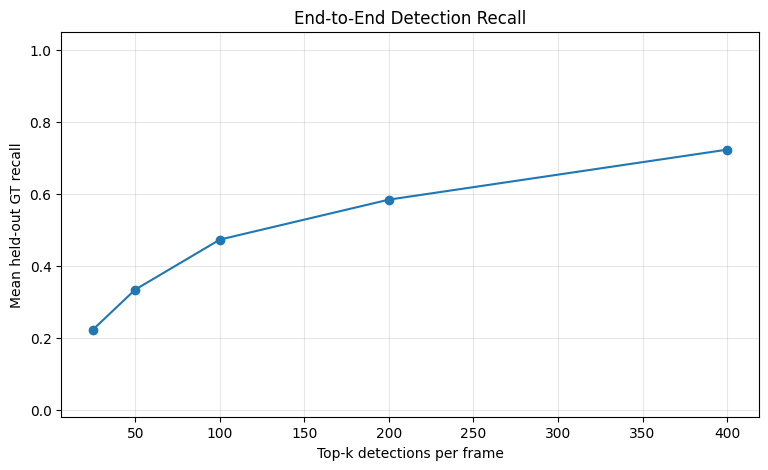

t=0: raw=7795, nms=1768, ranked=1768, selected=200, time=8.9s
t=1: raw=7532, nms=1773, ranked=1773, selected=200, time=8.9s
t=2: raw=7886, nms=1799, ranked=1799, selected=200, time=9.2s
t=3: raw=7641, nms=1798, ranked=1798, selected=200, time=9.0s
t=4: raw=7838, nms=1851, ranked=1851, selected=200, time=9.1s
t=5: raw=7421, nms=1754, ranked=1754, selected=200, time=9.0s
t=6: raw=7261, nms=1735, ranked=1735, selected=200, time=9.1s
t=7: raw=7317, nms=1729, ranked=1729, selected=200, time=9.0s
t=8: raw=7696, nms=1823, ranked=1823, selected=200, time=9.0s
t=9: raw=7892, nms=1854, ranked=1854, selected=200, time=9.2s
t=10: raw=8014, nms=1862, ranked=1862, selected=200, time=9.3s
t=11: raw=8196, nms=1941, ranked=1941, selected=200, time=9.5s
t=12: raw=7927, nms=1881, ranked=1881, selected=200, time=9.2s
t=13: raw=7853, nms=1879, ranked=1879, selected=200, time=9.4s
t=14: raw=8018, nms=1859, ranked=1859, selected=200, time=9.1s
t=15: raw=8052, nms=1890, ranked=1890, selected=200, time=9.2s
t=

,t,raw_candidates,nms_candidates,ranked_candidates,selected_candidates,graph_edges,elapsed_seconds
0,0,7795,1768,1768,200,24331,8.858621
1,1,7532,1773,1773,200,24399,8.929203
2,2,7886,1799,1799,200,24695,9.238741
3,3,7641,1798,1798,200,24756,8.992769
4,4,7838,1851,1851,200,25682,9.093923


,z,y,x,sigma,proposal_count,proposal_sources,proposal_peak_intensity,center_intensity,patch_mean,patch_max,patch_std,local_contrast,center_to_patch_max_dist,patch_com_offset,is_near_border,center_voxel,vol_mean,vol_std,vol_max,z_line_mean,z_line_std,z_line_max,center_over_vol_mean,center_minus_vol_mean,center_slice_minus_neighbor_mean,slice_mean_std,z_peak_offset,mass_center_offset_3d,peak_to_mean_ratio,bright_fraction,graph_neighbor_count,graph_mean_neighbor_distance,graph_min_neighbor_distance,graph_mean_neighbor_intensity,graph_mean_neighbor_contrast,graph_mean_neighbor_proposal_count,t,pred_dist,ranking_score,rank_position,detection_id
0,41,130,131,4.0,1,medium_strict,1754.0,1754.0,1583.678955,1790.0,139.085632,206.321045,1.000000,0.053404,0,1754.0,1588.271606,268.745636,2273.0,1818.000000,286.623810,2226.0,1.104345,165.728394,-19.833374,179.018341,1,0.156987,1.431115,0.432099,16.0,6.222860,1.625000,1660.5625,294.091064,1.7500,0,7.354238,-7.354238,1,chapter34_t0_0
1,24,123,85,4.0,3,large_sensitive|medium_sensitive|medium_strict,1279.0,1279.0,1216.271606,1353.0,77.352806,136.728394,1.414214,0.016496,0,1279.0,1073.913574,153.801559,1353.0,1160.599976,89.350098,1279.0,1.190971,205.086426,80.049438,114.613373,0,0.030025,1.259878,0.543210,16.0,7.320772,2.071477,1383.4375,293.540131,1.4375,0,7.437489,-7.437489,2,chapter34_t0_1
2,37,193,95,5.0,1,large_sensitive,1507.0,1507.0,1466.740723,1611.0,77.616463,144.259277,5.000000,0.085753,0,1507.0,1405.893799,155.466583,1770.0,1480.599976,92.300812,1627.0,1.071916,101.106201,30.573975,122.085503,1,0.134474,1.258986,0.530864,16.0,5.935493,1.723573,1556.0625,249.272369,1.4375,0,7.584010,-7.584010,3,chapter34_t0_2
3,17,255,95,5.0,1,large_sensitive,1195.0,1195.0,1210.688843,1365.0,86.613266,154.311157,2.000000,0.074207,1,1195.0,1058.982178,143.174789,1365.0,1064.800049,120.512901,1195.0,1.128442,136.017822,96.855469,116.555489,0,2.035556,1.288974,0.533333,16.0,9.283495,2.071477,1226.3125,199.058167,1.5000,0,7.949785,-7.949785,4,chapter34_t0_3
4,25,125,88,3.5,1,medium_sensitive,1192.0,1192.0,1120.629639,1292.0,94.925629,171.370361,1.414214,0.112793,0,1192.0,1013.817261,169.832870,1353.0,1115.599976,101.653534,1243.0,1.175754,178.182739,69.376587,109.624672,1,0.191783,1.334560,0.501235,16.0,7.531094,1.625000,1371.1875,286.811737,1.5625,0,8.260656,-8.260656,5,chapter34_t0_4


,t,num_selected,within_top_k_limit,rank_positions_valid,unique_coordinates
0,0,200,True,True,200
1,1,200,True,True,200
2,2,200,True,True,200
3,3,200,True,True,200
4,4,200,True,True,200


Output validation passed.
Saved: /kaggle/working/chapter34_top200_detections.csv
Saved: /kaggle/working/chapter34_full_ranked_candidates.csv
Saved: /kaggle/working/chapter34_frame_summary.csv
Saved: /kaggle/working/chapter34_validation_metrics.csv
Saved: /kaggle/working/chapter34_training_candidates.csv
Saved: /kaggle/working/chapter34_model_features.txt
Checkpoints: /kaggle/working/chapter34_checkpoints
Historical Chapter 34 pipeline function loaded.
Signature: (raw_volume, ranking_model, feature_columns: 'list[str]', timepoints: 'Iterable[int]', config: 'DetectionConfig' = DetectionConfig(sample_id='44b6_12dfb391', nms_radius=3.0, oracle_radius=6.0, target_distance_clip=20.0, graph_radius_physical=12.0, max_graph_neighbors=16, patch_radius_2d=4, patch_radius_z=2, patch_radius_xy=4, top_k=200, train_timesteps=(0, 8, 20, 40), validation_timesteps=(60, 80), coordinate_scale_zyx=(1.625, 0.40625, 0.40625)), top_k: 'Optional[int]' = None, checkpoint_directory: 'Optional[Path | str]' = None

In [7]:
CH34_NAME = "chapter-34-end-to-end-detection-pipeline.ipynb"
ch34_nb = load_nb(SOURCE_PATHS[CH34_NAME])
CH34_NS = make_exec_namespace("__chapter34_replay__")

for heading, sources in section_map(ch34_nb):
    if re.search(r"(plot|visuali[sz]|conclusion|next step)", heading, flags=re.I):
        continue
    for i, source in enumerate(sources):
        try:
            exec_code(source, CH34_NS, f"Chapter 34 / {heading} / {i}")
        except RuntimeError as exc:
            if "run_detection_pipeline" in CH34_NS:
                warnings.warn("Chapter 34 replay hit a later-cell error after run_detection_pipeline() was defined: " + str(exc))
                continue
            raise

if "run_detection_pipeline" not in CH34_NS:
    raise RuntimeError("Historical Chapter 34 did not expose run_detection_pipeline().")
run_detection_pipeline = CH34_NS["run_detection_pipeline"]
CH34_SIGNATURE = inspect.signature(run_detection_pipeline)
print("Historical Chapter 34 pipeline function loaded.")
print("Signature:", CH34_SIGNATURE)


def _looks_like_fitted_estimator(obj):
    """
    Reject estimator classes and prefer fitted estimator *instances*.

    V6 accidentally selected the imported HistGradientBoostingRegressor class
    itself because classes expose a predict method. Calling that unbound method
    produced:
        TypeError: HistGradientBoostingRegressor.predict()
        missing 1 required positional argument: 'X'
    """
    if obj is None or inspect.isclass(obj):
        return False

    if not (hasattr(obj, "predict") or hasattr(obj, "predict_proba")):
        return False

    # Scikit-learn fitted estimators normally acquire attributes ending in "_".
    fitted_attrs = [
        name
        for name in dir(obj)
        if name.endswith("_") and not name.startswith("__")
    ]

    return len(fitted_attrs) > 0


def _find_model_candidate(namespace):
    preferred = [
        "model",
        "best_model",
        "distance_model",
        "hist_model",
        "hist_distance_model",
        "ranking_model",
        "regressor",
        "rank_model",
        "detector_model",
    ]

    # First try likely historical variable names.
    for name in preferred:
        obj = namespace.get(name)
        if _looks_like_fitted_estimator(obj):
            return name, obj

    # Then inspect all namespace objects, but NEVER return an estimator class.
    candidates = []

    for name, obj in namespace.items():
        if name.startswith("_"):
            continue

        if not _looks_like_fitted_estimator(obj):
            continue

        fitted_attrs = [
            x
            for x in dir(obj)
            if x.endswith("_") and not x.startswith("__")
        ]

        candidates.append(
            (len(fitted_attrs), name, obj)
        )

    if candidates:
        # Prefer the object with the richest fitted state.
        candidates.sort(reverse=True, key=lambda x: x[0])
        _, name, obj = candidates[0]
        return name, obj

    return None, None


def _find_feature_columns_candidate(namespace):
    preferred=["feature_columns","FEATURE_COLUMNS","features","model_features","feature_names","training_features","GRAPH_FEATURE_COLUMNS"]
    for name in preferred:
        obj=namespace.get(name)
        if isinstance(obj,(list,tuple)) and obj and all(isinstance(x,str) for x in obj): return name,list(obj)
    for name,obj in namespace.items():
        if 'feature' in name.lower() and isinstance(obj,(list,tuple)) and obj and all(isinstance(x,str) for x in obj): return name,list(obj)
    return None,None

CH34_MODEL_NAME, CH34_MODEL = _find_model_candidate(CH34_NS)
CH34_FEATURE_NAME, CH34_FEATURE_COLUMNS = _find_feature_columns_candidate(CH34_NS)
print("Detected ranking model:", CH34_MODEL_NAME)
print("Ranking model Python type:", type(CH34_MODEL).__name__ if CH34_MODEL is not None else None)
print("Ranking model is class:", inspect.isclass(CH34_MODEL) if CH34_MODEL is not None else None)
print("Detected feature columns:", CH34_FEATURE_NAME)
if CH34_MODEL is None: raise RuntimeError("Could not recover frozen historical Chapter 34 ranking model.")
if CH34_FEATURE_COLUMNS is None: raise RuntimeError("Could not recover historical Chapter 34 feature columns.")


def _find_sample_zarr(sample_id: str) -> Path:
    for p in [TRAIN_DIR/f"{sample_id}.zarr", CONFIG.competition_dir/'train'/f"{sample_id}.zarr", CONFIG.competition_dir/'training'/f"{sample_id}.zarr"]:
        if p.exists(): return p
    matches=list(CONFIG.competition_dir.rglob(f"{sample_id}.zarr"))
    if matches: return matches[0]
    raise FileNotFoundError(f"Could not locate microscopy Zarr volume for sample {sample_id}.")


def _open_4d_volume(path: Path):
    root=zarr.open(path,mode='r')
    if hasattr(root,'ndim') and getattr(root,'ndim',None)==4: return root
    found=[]
    def visit(group,prefix=''):
        try:
            for key in group.array_keys():
                arr=group[key]
                if getattr(arr,'ndim',None)==4: found.append((prefix+key,arr))
            for key in group.group_keys(): visit(group[key],prefix+key+'/')
        except Exception: pass
    visit(root)
    if not found: raise RuntimeError(f"No 4-D microscopy array found inside {path}.")
    if len(found)>1: print('Multiple 4-D arrays found; using:',found[0][0])
    return found[0][1]


def _make_detection_config(sample_id: str):
    DetectionConfig=CH34_NS.get('DetectionConfig')
    if DetectionConfig is None: raise RuntimeError('Historical Chapter 34 DetectionConfig was not recovered.')
    try: return DetectionConfig(sample_id=sample_id)
    except TypeError:
        base=CH34_NS.get('CONFIG')
        if base is None: raise
        return replace(base,sample_id=sample_id)


def run_ch34_for_sample(sample_id: str):
    zarr_path=_find_sample_zarr(sample_id)
    raw_volume=_open_4d_volume(zarr_path)
    if len(raw_volume.shape)!=4: raise RuntimeError(f"Expected 4-D volume; got {raw_volume.shape}")
    timepoints=range(int(raw_volume.shape[0]))
    config=_make_detection_config(sample_id)
    checkpoint_dir=CONFIG.per_sample_dir/sample_id/'chapter34_checkpoints'
    checkpoint_dir.mkdir(parents=True,exist_ok=True)
    print('Ch34 sample:',sample_id)
    print('  zarr:',zarr_path)
    print('  raw volume shape:',raw_volume.shape)
    print('  timepoints:',raw_volume.shape[0])
    print('  config sample_id:',getattr(config,'sample_id',None))
    return run_detection_pipeline(raw_volume, CH34_MODEL, CH34_FEATURE_COLUMNS, timepoints,
                                  config=config, top_k=200,
                                  checkpoint_directory=checkpoint_dir)

## 6. Bootstrap Chapter 35–37 definitions and adapters

Chapter 35 exposes `track_sequence(...)`. Chapters 36–37 are replayed by executing their historical algorithm sections after injecting the current sample's upstream DataFrames.

No target-GT oracle/evaluation/training section is executed.

In [8]:
CH35_NAME = "chapter-35-motion-aware-tracking-with-gap-closin.ipynb"
CH36_NAME = "chapter-36-track-aware-detection-filtering.ipynb"
CH37_NAME = "chapter-37-track-refinement-and-gap-closing.ipynb"

ch35_nb = load_nb(SOURCE_PATHS[CH35_NAME])
ch36_nb = load_nb(SOURCE_PATHS[CH36_NAME])
ch37_nb = load_nb(SOURCE_PATHS[CH37_NAME])

CH35_DEFS = bootstrap_definition_cells(ch35_nb, "chapter35")
CH36_DEFS = bootstrap_definition_cells(ch36_nb, "chapter36")
CH37_DEFS = bootstrap_definition_cells(ch37_nb, "chapter37")

if "track_sequence" not in CH35_DEFS:
    recovered_functions = sorted(
        name
        for name, obj in CH35_DEFS.items()
        if callable(obj) and not name.startswith("_")
    )
    raise RuntimeError(
        "Could not recover historical Chapter 35 track_sequence(). "
        "This indicates a replay/bootstrap mismatch, not evidence that the "
        "historical notebook lacks the function. "
        f"Recovered callables: {recovered_functions}"
    )

print("Chapter 35 track_sequence recovered.")
print("Chapter 35 reusable signature:", inspect.signature(CH35_DEFS["track_sequence"]))

Chapter 35 track_sequence recovered.
Chapter 35 reusable signature: (detections: 'pd.DataFrame', config: 'TrackingConfig' = TrackingConfig(sample_id='44b6_12dfb391', z_scale=1.625, y_scale=0.40625, x_scale=0.40625, max_link_distance=6.0, max_gap=2, rank_penalty_weight=0.35, pred_dist_penalty_weight=0.15, velocity_change_penalty_weight=0.25, node_match_radius=6.0))


In [9]:
def make_stage_config(ns, class_name: str, sample_id: str):
    cls = ns.get(class_name)
    if cls is None:
        return ns.get("CONFIG")

    try:
        return cls(sample_id=sample_id)
    except TypeError:
        base = ns.get("CONFIG")
        if base is not None:
            try:
                return replace(base, sample_id=sample_id)
            except Exception:
                return base
        return cls()


def run_ch35(detections_df: pd.DataFrame, sample_id: str):
    ns = dict(CH35_DEFS)
    config = make_stage_config(ns, "TrackingConfig", sample_id)

    det = detections_df.copy()

    # Historical Ch35 physical-coordinate convention.
    for axis, attr in (
        ("z", "z_scale"),
        ("y", "y_scale"),
        ("x", "x_scale"),
    ):
        physical = f"{axis}_physical"
        if physical not in det.columns:
            det[physical] = (
                det[axis].astype(float)
                * float(getattr(config, attr))
            )

    result = ns["track_sequence"](det, config=config)

    if not isinstance(result, tuple) or len(result) < 2:
        raise RuntimeError(
            "Historical track_sequence() returned an unexpected result."
        )

    nodes = result[0].copy()
    edges = result[1].copy()

    summary_fn = (
        ns.get("summarize_tracks")
        or ns.get("build_track_summary")
        or ns.get("track_summary")
    )

    if callable(summary_fn):
        try:
            summary = summary_fn(nodes, edges)
        except TypeError:
            summary = summary_fn(nodes)
    else:
        # Orchestration-only summary; tracking decisions are unchanged.
        summary = (
            nodes.groupby("track_id", as_index=False)
            .agg(
                start_t=("t", "min"),
                end_t=("t", "max"),
                num_detections=("t", "size"),
                mean_rank=("rank_position", "mean"),
                mean_pred_dist=("pred_dist", "mean"),
            )
        )

    return nodes, edges, summary


def run_ch36(
    detections_df: pd.DataFrame,
    ch35_nodes: pd.DataFrame,
    ch35_edges: pd.DataFrame,
    ch35_summary: pd.DataFrame,
    sample_id: str,
):
    ns = dict(CH36_DEFS)
    ns.update(
        {
            "detections_df": detections_df.copy(),
            "track_nodes_df": ch35_nodes.copy(),
            "track_edges_df": ch35_edges.copy(),
            "track_summary_df": ch35_summary.copy(),
        }
    )

    ns["CONFIG"] = make_stage_config(
        ns, "FilteringConfig", sample_id
    )

    # Exact historical feature + label-free support sections.
    run_heading_sections(
        ch36_nb,
        ns,
        include_patterns=[
            r"Step 2\b",
            r"Step 3\b",
            r"Step 4\b",
            r"Step 5\b",
            r"Step 6\b",
        ],
    )

    if "feature_df" not in ns:
        raise RuntimeError(
            "Chapter 36 replay did not produce feature_df."
        )

    feature_df = ns["feature_df"].copy()

    # Frozen-model only. Never fit on a new target sample.
    frozen_model = CH36_DEFS.get("FROZEN_TEMPORAL_MODEL")
    model_features = CH36_DEFS.get("MODEL_FEATURE_COLUMNS")

    if frozen_model is not None and model_features is not None:
        x = feature_df[list(model_features)].fillna(0.0)
        feature_df["temporal_model_probability"] = (
            frozen_model.predict_proba(x)[:, 1]
        )
        feature_df["final_filter_score"] = (
            0.60 * feature_df["temporal_model_probability"]
            + 0.40 * feature_df["temporal_support_score"]
        )
        filter_mode = "frozen_historical_temporal_model"
    else:
        feature_df["temporal_model_probability"] = np.nan
        feature_df["final_filter_score"] = (
            feature_df["temporal_support_score"]
        )
        filter_mode = "historical_label_free_temporal_support"

    ns["feature_df"] = feature_df

    # Exact historical selection and filtered graph construction.
    run_heading_sections(
        ch36_nb,
        ns,
        include_patterns=[
            r"Step 10\b",
            r"Step 11\b",
        ],
    )

    filtered = ns.get("filtered_detections_df")
    nodes = ns.get("filtered_track_nodes_df")
    edges = ns.get("filtered_track_edges_df")

    if filtered is None:
        raise RuntimeError(
            "Chapter 36 replay did not produce filtered_detections_df."
        )

    if nodes is None:
        ids = set(filtered["detection_id"].astype(str))
        nodes = ch35_nodes[
            ch35_nodes["detection_id"].astype(str).isin(ids)
        ].copy()

    if edges is None:
        edge_cols = set(ch35_edges.columns)
        source_col = next(
            (
                c for c in (
                    "source_detection_id",
                    "source_id",
                    "source",
                )
                if c in edge_cols
            ),
            None,
        )
        target_col = next(
            (
                c for c in (
                    "target_detection_id",
                    "target_id",
                    "target",
                )
                if c in edge_cols
            ),
            None,
        )

        if source_col and target_col:
            ids = set(filtered["detection_id"].astype(str))
            edges = ch35_edges[
                ch35_edges[source_col].astype(str).isin(ids)
                & ch35_edges[target_col].astype(str).isin(ids)
            ].copy()
        else:
            edges = pd.DataFrame()

    return filtered.copy(), nodes.copy(), edges.copy(), filter_mode


def run_ch37(
    ch36_filtered: pd.DataFrame,
    ch36_nodes: pd.DataFrame,
    ch36_edges: pd.DataFrame,
    sample_id: str,
):
    ns = dict(CH37_DEFS)
    ns.update(
        {
            "filtered_detections_df": ch36_filtered.copy(),
            "filtered_track_nodes_df": ch36_nodes.copy(),
            "filtered_track_edges_df": ch36_edges.copy(),
            "detections_df": ch36_filtered.copy(),
            "track_nodes_df": ch36_nodes.copy(),
            "track_edges_df": ch36_edges.copy(),
        }
    )

    ns["CONFIG"] = make_stage_config(
        ns, "RefinementConfig", sample_id
    )

    run_heading_sections(
        ch37_nb,
        ns,
        include_patterns=[r"## Step"],
        skip_patterns=[
            r"(locate|load).*chapter 36",
            r"ground truth",
            r"\bGT\b",
            r"evaluat",
            r"validat",
            r"plot",
            r"visual",
            r"save",
        ],
    )

    nodes = (
        ns.get("refined_track_nodes_df")
        if ns.get("refined_track_nodes_df") is not None
        else ns.get("refined_nodes_df")
    )
    edges = (
        ns.get("refined_track_edges_df")
        if ns.get("refined_track_edges_df") is not None
        else ns.get("refined_edges_df")
    )
    summary = (
        ns.get("refined_track_summary_df")
        if ns.get("refined_track_summary_df") is not None
        else ns.get("track_summary_df")
    )

    if nodes is None or edges is None:
        raise RuntimeError(
            "Chapter 37 replay did not expose refined nodes/edges. "
            "Update only this adapter if historical variable names changed."
        )

    if summary is None:
        summary = (
            nodes.groupby("track_id", as_index=False)
            .agg(
                start_t=("t", "min"),
                end_t=("t", "max"),
                num_detections=("t", "size"),
            )
        )

    return nodes.copy(), edges.copy(), summary.copy()

## 7. Run the frozen pipeline per selected sample

Each sample is processed independently. Any stage exception is recorded in `chapter46a_failures.csv`; the sample is not silently omitted.

In [10]:
FAILURES = []
VALIDATION = []
SAMPLE_SUMMARY = []

CH34_ALL = []
CH35_NODES_ALL = []
CH35_EDGES_ALL = []
CH35_SUMMARY_ALL = []
CH36_DET_ALL = []
CH36_NODES_ALL = []
CH36_EDGES_ALL = []
CH37_NODES_ALL = []
CH37_EDGES_ALL = []
CH37_SUMMARY_ALL = []


def record_failure(sample_id: str, stage: str, exc: Exception):
    FAILURES.append(
        {
            "sample_id": sample_id,
            "stage": stage,
            "error_type": type(exc).__name__,
            "message": str(exc),
            "traceback": traceback.format_exc(),
        }
    )


def strip_qualifiers(df: pd.DataFrame) -> pd.DataFrame:
    drop = [
        c
        for c in df.columns
        if c == "sample_id" or c.startswith("global_")
    ]
    return df.drop(columns=drop, errors="ignore").copy()


for _, selected in selected_samples.iterrows():
    sample_id = str(selected["sample_id"])
    gt_binary_divisions = int(selected["gt_binary_divisions"])
    sample_dir = CONFIG.per_sample_dir / sample_id
    sample_dir.mkdir(parents=True, exist_ok=True)

    status = {
        "sample_id": sample_id,
        "gt_binary_divisions": gt_binary_divisions,
        "ch34_ok": False,
        "ch35_ok": False,
        "ch36_ok": False,
        "ch37_ok": False,
        "filter_mode": "",
        "final_status": "FAILED",
    }

    ch34_rows = np.nan
    ch36_rows = np.nan
    ch37_nodes_n = np.nan
    ch37_tracks_n = np.nan

    print("\n" + "=" * 90)
    print(
        "SAMPLE:", sample_id,
        "| GT binary divisions:", gt_binary_divisions,
    )

    # ---------------- Chapter 34 ----------------
    try:
        result = run_ch34_for_sample(sample_id)

        if isinstance(result, pd.DataFrame):
            ch34_df = result.copy()
        elif isinstance(result, tuple):
            frames = [
                x for x in result
                if isinstance(x, pd.DataFrame)
            ]
            if not frames:
                raise RuntimeError(
                    "Chapter 34 returned no DataFrame."
                )
            ch34_df = max(frames, key=len).copy()
        else:
            raise RuntimeError(
                f"Unexpected Chapter 34 result type: {type(result)}"
            )

        if "rank_position" not in ch34_df.columns:
            raise RuntimeError(
                "Chapter 34 output lacks rank_position."
            )

        # Preserve top-200-per-timepoint contract.
        ch34_df = (
            ch34_df.sort_values(["t", "rank_position"])
            .groupby("t", group_keys=False)
            .head(200)
            .reset_index(drop=True)
        )

        ch34_df.insert(0, "sample_id", sample_id)
        ch34_df.to_csv(
            sample_dir / "chapter34_top200_detections.csv",
            index=False,
        )

        CH34_ALL.append(ch34_df)
        ch34_rows = len(ch34_df)
        status["ch34_ok"] = True
        print("Ch34:", ch34_rows, "rows")

    except Exception as exc:
        record_failure(sample_id, "chapter34", exc)
        print("FAILED Ch34:", exc)
        VALIDATION.append(status)
        SAMPLE_SUMMARY.append(
            {
                "sample_id": sample_id,
                "gt_binary_divisions": gt_binary_divisions,
                "ch34_rows": ch34_rows,
                "ch36_rows": ch36_rows,
                "ch37_nodes": ch37_nodes_n,
                "ch37_track_count": ch37_tracks_n,
            }
        )
        continue

    # ---------------- Chapter 35 ----------------
    try:
        ch35_nodes, ch35_edges, ch35_summary = run_ch35(
            strip_qualifiers(ch34_df),
            sample_id,
        )

        ch35_nodes = qualify_track_ids(
            ch35_nodes, sample_id
        )
        ch35_edges = qualify_track_ids(
            ch35_edges, sample_id
        )
        ch35_summary = qualify_track_ids(
            ch35_summary, sample_id
        )

        ch35_nodes.to_csv(
            sample_dir / "chapter35_track_nodes.csv",
            index=False,
        )
        ch35_edges.to_csv(
            sample_dir / "chapter35_track_edges.csv",
            index=False,
        )
        ch35_summary.to_csv(
            sample_dir / "chapter35_track_summary.csv",
            index=False,
        )

        CH35_NODES_ALL.append(ch35_nodes)
        CH35_EDGES_ALL.append(ch35_edges)
        CH35_SUMMARY_ALL.append(ch35_summary)

        status["ch35_ok"] = True
        print(
            "Ch35:",
            len(ch35_nodes), "nodes,",
            len(ch35_edges), "edges,",
            ch35_nodes["track_id"].nunique()
            if "track_id" in ch35_nodes.columns
            else "n/a",
            "tracks",
        )

    except Exception as exc:
        record_failure(sample_id, "chapter35", exc)
        print("FAILED Ch35:", exc)
        VALIDATION.append(status)
        SAMPLE_SUMMARY.append(
            {
                "sample_id": sample_id,
                "gt_binary_divisions": gt_binary_divisions,
                "ch34_rows": ch34_rows,
                "ch36_rows": ch36_rows,
                "ch37_nodes": ch37_nodes_n,
                "ch37_track_count": ch37_tracks_n,
            }
        )
        continue

    # ---------------- Chapter 36 ----------------
    try:
        (
            ch36_filtered,
            ch36_nodes,
            ch36_edges,
            filter_mode,
        ) = run_ch36(
            strip_qualifiers(ch34_df),
            strip_qualifiers(ch35_nodes),
            strip_qualifiers(ch35_edges),
            strip_qualifiers(ch35_summary),
            sample_id,
        )

        ch36_filtered = qualify_track_ids(
            ch36_filtered, sample_id
        )
        ch36_nodes = qualify_track_ids(
            ch36_nodes, sample_id
        )
        ch36_edges = qualify_track_ids(
            ch36_edges, sample_id
        )

        ch36_filtered.to_csv(
            sample_dir / "chapter36_filtered_detections.csv",
            index=False,
        )
        ch36_nodes.to_csv(
            sample_dir / "chapter36_filtered_track_nodes.csv",
            index=False,
        )
        ch36_edges.to_csv(
            sample_dir / "chapter36_filtered_track_edges.csv",
            index=False,
        )

        CH36_DET_ALL.append(ch36_filtered)
        CH36_NODES_ALL.append(ch36_nodes)
        CH36_EDGES_ALL.append(ch36_edges)

        ch36_rows = len(ch36_filtered)
        status["ch36_ok"] = True
        status["filter_mode"] = filter_mode
        print("Ch36:", ch36_rows, "rows |", filter_mode)

    except Exception as exc:
        record_failure(sample_id, "chapter36", exc)
        print("FAILED Ch36:", exc)
        VALIDATION.append(status)
        SAMPLE_SUMMARY.append(
            {
                "sample_id": sample_id,
                "gt_binary_divisions": gt_binary_divisions,
                "ch34_rows": ch34_rows,
                "ch36_rows": ch36_rows,
                "ch37_nodes": ch37_nodes_n,
                "ch37_track_count": ch37_tracks_n,
            }
        )
        continue

    # ---------------- Chapter 37 ----------------
    try:
        ch37_nodes, ch37_edges, ch37_summary = run_ch37(
            strip_qualifiers(ch36_filtered),
            strip_qualifiers(ch36_nodes),
            strip_qualifiers(ch36_edges),
            sample_id,
        )

        ch37_nodes = qualify_track_ids(
            ch37_nodes, sample_id
        )
        ch37_edges = qualify_track_ids(
            ch37_edges, sample_id
        )
        ch37_summary = qualify_track_ids(
            ch37_summary, sample_id
        )

        ch37_nodes.to_csv(
            sample_dir / "chapter37_refined_track_nodes.csv",
            index=False,
        )
        ch37_edges.to_csv(
            sample_dir / "chapter37_refined_track_edges.csv",
            index=False,
        )
        ch37_summary.to_csv(
            sample_dir / "chapter37_refined_track_summary.csv",
            index=False,
        )

        CH37_NODES_ALL.append(ch37_nodes)
        CH37_EDGES_ALL.append(ch37_edges)
        CH37_SUMMARY_ALL.append(ch37_summary)

        ch37_nodes_n = len(ch37_nodes)
        ch37_tracks_n = (
            ch37_nodes["track_id"].nunique()
            if "track_id" in ch37_nodes.columns
            else np.nan
        )

        status["ch37_ok"] = True
        status["final_status"] = "COMPLETE"

        print(
            "Ch37:",
            ch37_nodes_n, "nodes,",
            ch37_tracks_n, "tracks",
        )

    except Exception as exc:
        record_failure(sample_id, "chapter37", exc)
        print("FAILED Ch37:", exc)

    VALIDATION.append(status)
    SAMPLE_SUMMARY.append(
        {
            "sample_id": sample_id,
            "gt_binary_divisions": gt_binary_divisions,
            "ch34_rows": ch34_rows,
            "ch36_rows": ch36_rows,
            "ch37_nodes": ch37_nodes_n,
            "ch37_track_count": ch37_tracks_n,
        }
    )


SAMPLE: 6bba_48816121 | GT binary divisions: 5
Ch34 sample: 6bba_48816121
  zarr: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/6bba_48816121.zarr
  raw volume shape: (100, 64, 256, 256)
  timepoints: 100
  config sample_id: 6bba_48816121
FAILED Ch34: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- bright_fraction
- center_intensity
- center_minus_vol_mean
- center_over_vol_mean
- center_slice_minus_neighbor_mean
- ...



## 8. Combine multi-sample artifacts

In [11]:
def concat_or_empty(frames):
    return (
        pd.concat(frames, ignore_index=True)
        if frames
        else pd.DataFrame()
    )


combined_outputs = {
    "chapter34_top200_detections_multisample.csv":
        concat_or_empty(CH34_ALL),

    "chapter35_track_nodes_multisample.csv":
        concat_or_empty(CH35_NODES_ALL),

    "chapter35_track_edges_multisample.csv":
        concat_or_empty(CH35_EDGES_ALL),

    "chapter35_track_summary_multisample.csv":
        concat_or_empty(CH35_SUMMARY_ALL),

    "chapter36_filtered_detections_multisample.csv":
        concat_or_empty(CH36_DET_ALL),

    "chapter36_filtered_track_nodes_multisample.csv":
        concat_or_empty(CH36_NODES_ALL),

    "chapter36_filtered_track_edges_multisample.csv":
        concat_or_empty(CH36_EDGES_ALL),

    "chapter37_refined_track_nodes_multisample.csv":
        concat_or_empty(CH37_NODES_ALL),

    "chapter37_refined_track_edges_multisample.csv":
        concat_or_empty(CH37_EDGES_ALL),

    "chapter37_refined_track_summary_multisample.csv":
        concat_or_empty(CH37_SUMMARY_ALL),
}

for filename, df in combined_outputs.items():
    path = CONFIG.output_dir / filename
    df.to_csv(path, index=False)
    print(f"{filename}: {len(df):,} rows")

chapter34_top200_detections_multisample.csv: 0 rows
chapter35_track_nodes_multisample.csv: 0 rows
chapter35_track_edges_multisample.csv: 0 rows
chapter35_track_summary_multisample.csv: 0 rows
chapter36_filtered_detections_multisample.csv: 0 rows
chapter36_filtered_track_nodes_multisample.csv: 0 rows
chapter36_filtered_track_edges_multisample.csv: 0 rows
chapter37_refined_track_nodes_multisample.csv: 0 rows
chapter37_refined_track_edges_multisample.csv: 0 rows
chapter37_refined_track_summary_multisample.csv: 0 rows


## 9. Required per-sample summary and explicit validation

In [12]:
sample_summary_df = pd.DataFrame(SAMPLE_SUMMARY)
validation_df = pd.DataFrame(VALIDATION)
failures_df = pd.DataFrame(FAILURES)

sample_summary_df.to_csv(
    CONFIG.output_dir / "chapter46a_sample_summary.csv",
    index=False,
)
validation_df.to_csv(
    CONFIG.output_dir / "chapter46a_validation.csv",
    index=False,
)
failures_df.to_csv(
    CONFIG.output_dir / "chapter46a_failures.csv",
    index=False,
)

print("Per-sample summary:")
display(sample_summary_df)

print("\nValidation:")
display(validation_df)

if len(failures_df):
    print("\nFailures:")
    display(
        failures_df[
            ["sample_id", "stage", "error_type", "message"]
        ]
    )
else:
    print("\nNo stage failures recorded.")

Per-sample summary:


,sample_id,gt_binary_divisions,ch34_rows,ch36_rows,ch37_nodes,ch37_track_count
0,6bba_48816121,5,NaN,NaN,NaN,NaN



Validation:


,sample_id,gt_binary_divisions,ch34_ok,ch35_ok,ch36_ok,ch37_ok,filter_mode,final_status
0,6bba_48816121,5,False,False,False,False,,FAILED



Failures:


,sample_id,stage,error_type,message
0,6bba_48816121,chapter34,ValueError,The feature names should match those that were...


In [13]:
required_tables = {
    "ch34":
        combined_outputs[
            "chapter34_top200_detections_multisample.csv"
        ],
    "ch35_nodes":
        combined_outputs[
            "chapter35_track_nodes_multisample.csv"
        ],
    "ch35_edges":
        combined_outputs[
            "chapter35_track_edges_multisample.csv"
        ],
    "ch36":
        combined_outputs[
            "chapter36_filtered_detections_multisample.csv"
        ],
    "ch37_nodes":
        combined_outputs[
            "chapter37_refined_track_nodes_multisample.csv"
        ],
    "ch37_edges":
        combined_outputs[
            "chapter37_refined_track_edges_multisample.csv"
        ],
}

selected_ids = set(
    selected_samples["sample_id"].astype(str)
)

coverage_rows = []

for sample_id in sorted(selected_ids):
    row = {"sample_id": sample_id}

    for stage_name, df in required_tables.items():
        present = (
            (not df.empty)
            and ("sample_id" in df.columns)
            and (
                df["sample_id"]
                .astype(str)
                .eq(sample_id)
                .any()
            )
        )
        row[f"{stage_name}_present"] = bool(present)

    presence_flags = [
        v
        for k, v in row.items()
        if k.endswith("_present")
    ]
    row["all_required_artifacts_present"] = all(
        presence_flags
    )
    coverage_rows.append(row)

coverage_df = pd.DataFrame(coverage_rows)
coverage_df.to_csv(
    CONFIG.output_dir / "chapter46a_artifact_coverage.csv",
    index=False,
)

display(coverage_df)

missing = coverage_df[
    ~coverage_df["all_required_artifacts_present"]
]

if len(missing):
    print(
        f"INCOMPLETE: {len(missing)} selected samples are "
        "missing at least one required downstream artifact."
    )
else:
    print(
        f"COMPLETE: all {len(selected_ids)} selected samples "
        "appear in every required downstream artifact."
    )

,sample_id,ch34_present,ch35_nodes_present,ch35_edges_present,ch36_present,ch37_nodes_present,ch37_edges_present,all_required_artifacts_present
0,6bba_48816121,False,False,False,False,False,False,False


INCOMPLETE: 1 selected samples are missing at least one required downstream artifact.


## 10. Package the generated artifacts

In [14]:
zip_path = (
    CONFIG.output_dir
    / "chapter46a_multisample_pipeline_artifacts.zip"
)

csv_paths = sorted(
    CONFIG.output_dir.glob("*.csv")
)

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as zf:
    for path in csv_paths:
        zf.write(path, arcname=path.name)

run_manifest = {
    "selected_sample_count": int(len(selected_samples)),
    "complete_sample_count": int(
        validation_df["final_status"]
        .eq("COMPLETE")
        .sum()
        if "final_status" in validation_df.columns
        else 0
    ),
    "failure_count": int(len(failures_df)),
    "historical_sample_id": CONFIG.historical_sample_id,
    "strict_complete": CONFIG.strict_complete,
    "package": str(zip_path),
}

with (
    CONFIG.output_dir
    / "chapter46a_run_manifest.json"
).open("w") as f:
    json.dump(run_manifest, f, indent=2)

print("Saved:", zip_path)
print(json.dumps(run_manifest, indent=2))

Saved: /kaggle/working/chapter46a/chapter46a_multisample_pipeline_artifacts.zip
{
  "selected_sample_count": 1,
  "complete_sample_count": 0,
  "failure_count": 1,
  "historical_sample_id": "44b6_12dfb391",
  "strict_complete": false,
  "package": "/kaggle/working/chapter46a/chapter46a_multisample_pipeline_artifacts.zip"
}


## 11. Completion gate

Chapter 46A is complete only when:

- multiple selected samples contain binary GT divisions;
- every selected sample reaches Chapter 37;
- every required combined artifact contains `sample_id`;
- tracks are generated independently per sample and receive globally-qualified IDs before concatenation;
- no failed sample is hidden;
- the required summary is populated;
- `chapter46a_multisample_pipeline_artifacts.zip` exists.

Once this gate passes, point the existing Chapter 46 audit at the generated multi-sample Chapter 34, Chapter 36, and Chapter 37 CSVs.

In [15]:
complete_count = int(validation_df["final_status"].eq("COMPLETE").sum() if "final_status" in validation_df.columns else 0)
print(f"Chapter 46A smoke-test complete samples: {complete_count}/{len(selected_samples)}")
if complete_count == len(selected_samples) and complete_count > 0:
    print("\n✓ SMOKE TEST PASSED.")
    print("The selected sample reached Chapter 37. For the full cohort, change CONFIG.max_selected_samples from 1 to None.")
else:
    print("\n⚠ SMOKE TEST DID NOT REACH CHAPTER 37.")
    print("Do NOT run the full cohort. Inspect chapter46a_failures.csv and fix the next failing stage first.")
print("\nNo final RuntimeError is raised in v6.")

Chapter 46A smoke-test complete samples: 0/1

⚠ SMOKE TEST DID NOT REACH CHAPTER 37.
Do NOT run the full cohort. Inspect chapter46a_failures.csv and fix the next failing stage first.

No final RuntimeError is raised in v6.
